<a href="https://colab.research.google.com/github/4rdnac/PCVK_Ganjil_2025/blob/main/Week5_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

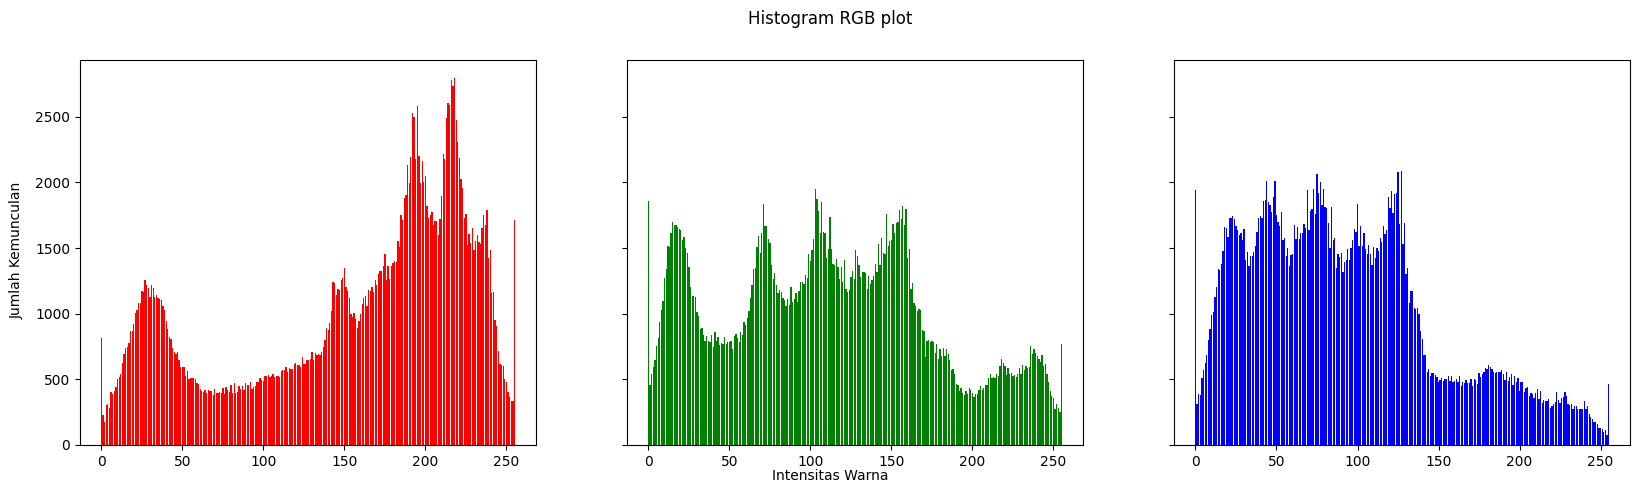

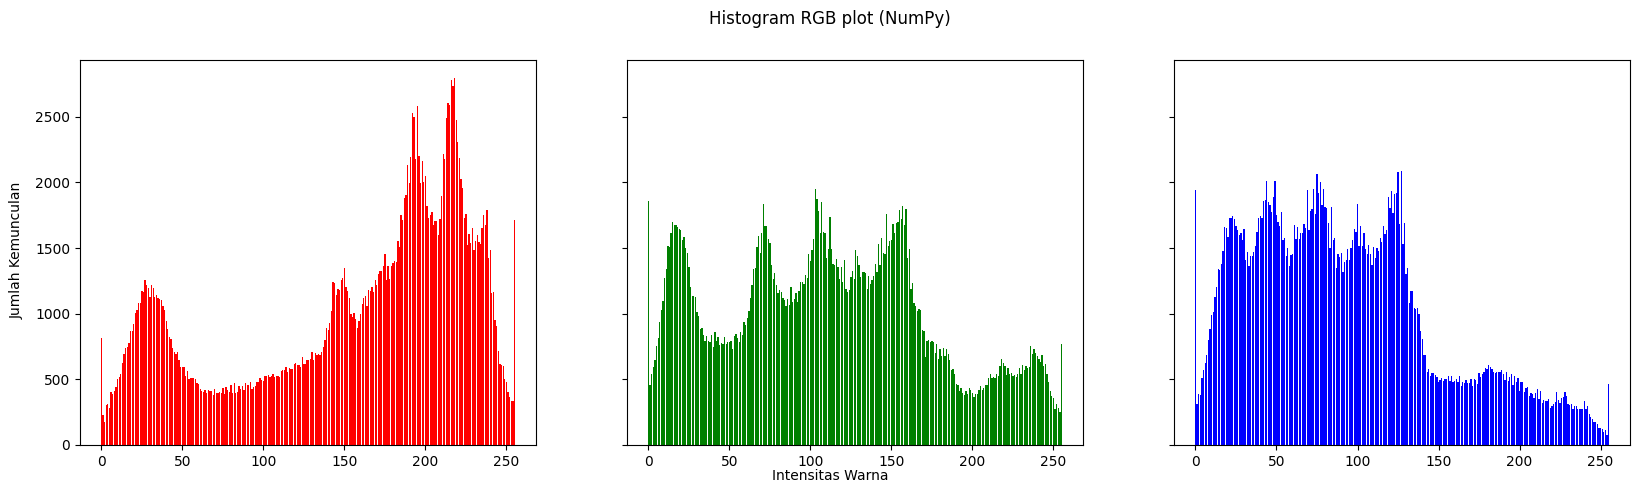

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

red_hist, _ = np.histogram(img[:,:,0].ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(img[:,:,1].ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(img[:,:,2].ravel(), bins=256, range=(0,256))

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')

plt.show()

# PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

Jawab:

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

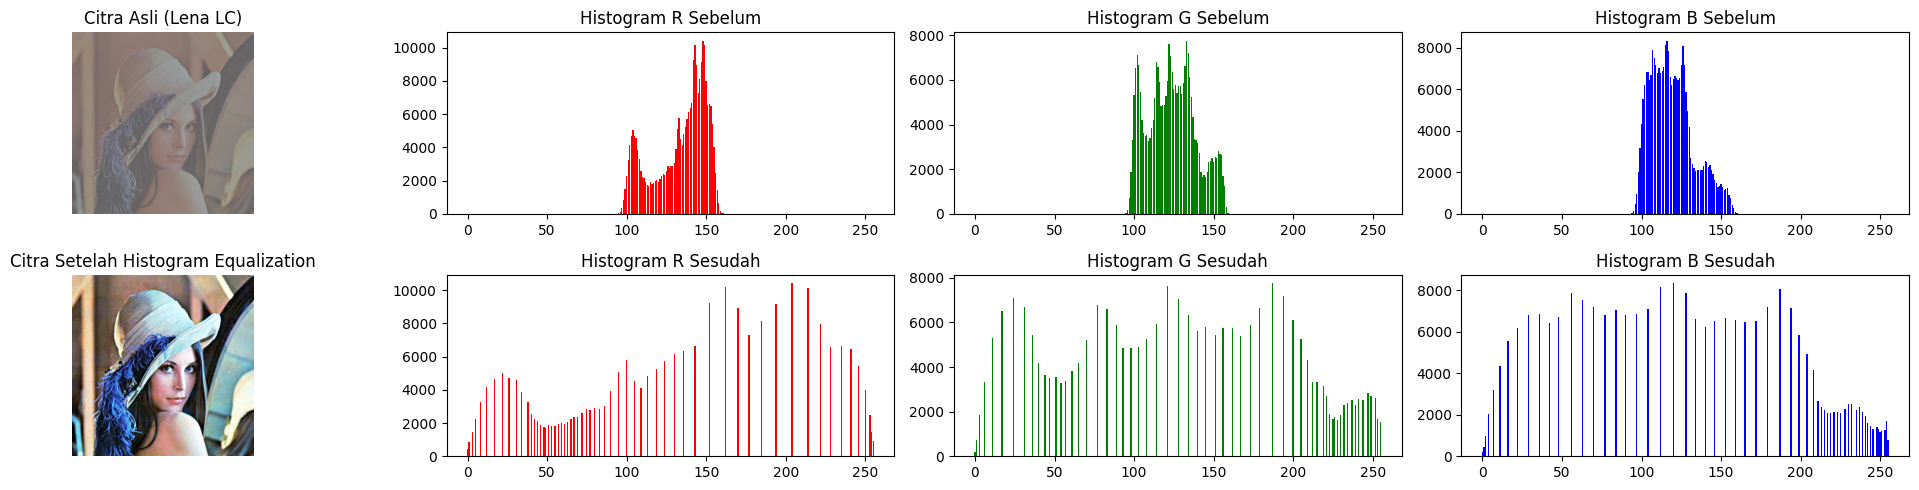

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

equ = cv.merge([r_eq, g_eq, b_eq])

# Hitung histogram sebelum
red_hist, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
red_hist_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
green_hist_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
blue_hist_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))

names = np.arange(256)

fig, axs = plt.subplots(2, 4, figsize=(20,5))

axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, red_hist, color='red')
axs[0,1].set_title("Histogram R Sebelum")

axs[0,2].bar(names, green_hist, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, blue_hist, color='blue')
axs[0,3].set_title("Histogram B Sebelum")

axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, red_hist_eq, color='red')
axs[1,1].set_title("Histogram R Sesudah")

axs[1,2].bar(names, green_hist_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, blue_hist_eq, color='blue')
axs[1,3].set_title("Histogram B Sesudah")

plt.tight_layout()
plt.show()

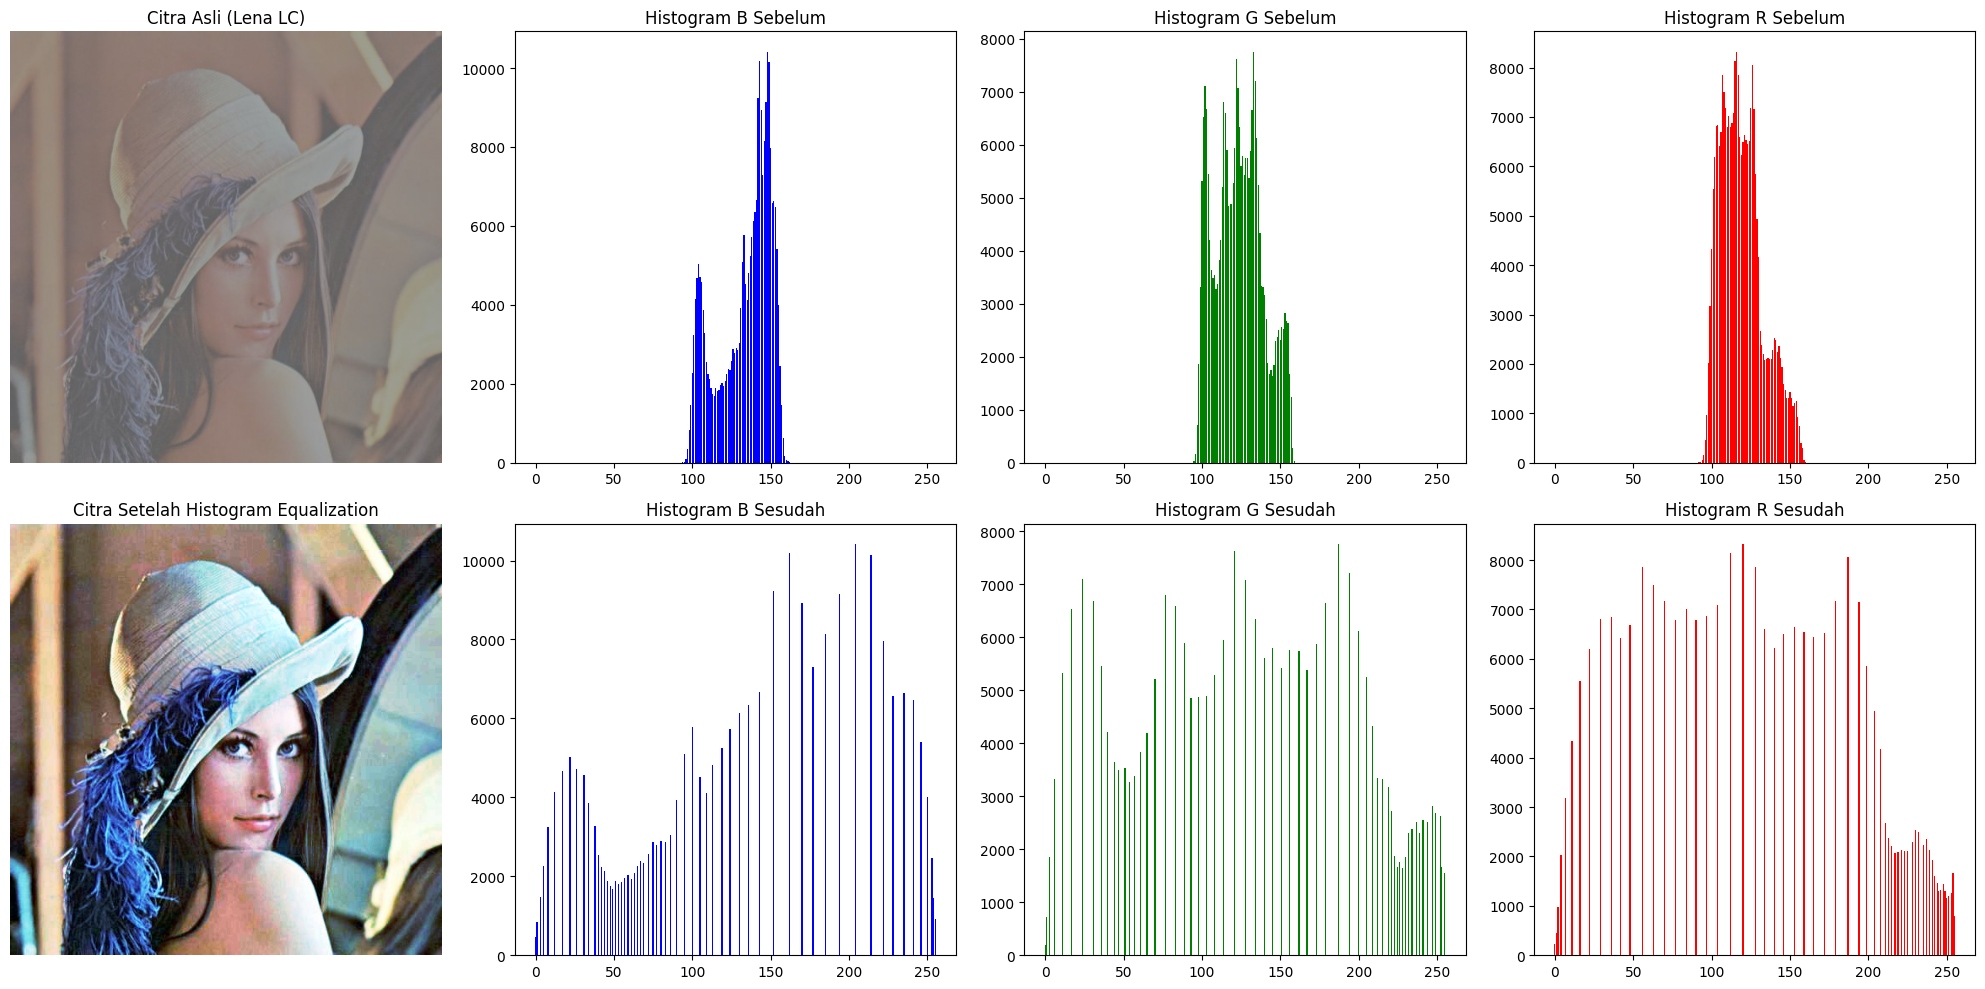

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('/content/drive/MyDrive/PCVK/images/lena_lc.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

b, g, r = cv.split(image)

# Equalization per channel
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

equ = cv.merge([b_equalized, g_equalized, r_equalized])

hist_b, _ = np.histogram(b.ravel(), bins=256, range=(0,256))
hist_g, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
hist_r, _ = np.histogram(r.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
hist_b_eq, _ = np.histogram(b_equalized.ravel(), bins=256, range=(0,256))
hist_g_eq, _ = np.histogram(g_equalized.ravel(), bins=256, range=(0,256))
hist_r_eq, _ = np.histogram(r_equalized.ravel(), bins=256, range=(0,256))

names = np.arange(256)

fig, axs = plt.subplots(2, 4, figsize=(20,10))

axs[0,0].imshow(image)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, hist_b, color='blue')
axs[0,1].set_title("Histogram B Sebelum")

axs[0,2].bar(names, hist_g, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, hist_r, color='red')
axs[0,3].set_title("Histogram R Sebelum")

axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, hist_b_eq, color='blue')
axs[1,1].set_title("Histogram B Sesudah")

axs[1,2].bar(names, hist_g_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, hist_r_eq, color='red')
axs[1,3].set_title("Histogram R Sesudah")

plt.tight_layout()
plt.show()
